# Module 2 — Real data (fits and rates)

Loads the reduced empirical series and produces three figures:

1. `fig_6.pdf` — 2×2 panel with the branching relation `D_w(D)` and the
   intrinsic-time rate `dt/dtau` against `w`, for patents and papers;
2. `fig_1.pdf` — 1×2 rate figure with twin y-axes: individual productivity,
   yearly event count, and active explorers;
3. `fig_SI1.pdf` — author-year activity heatmaps.

It also prints the inter-event time and career-length statistics quoted in
the Supporting Information. Run Module 1 first.


## Imports and configuration

All inputs come from `outputs/`; the figure style is set centrally by
`lib/plot_style.py`.


In [1]:
# Repository bootstrap.
# The notebooks are meant to be run from the repository root; the walk keeps
# them working when a front-end starts the kernel in a subdirectory.
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "lib").is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / "lib") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "lib"))

OUTPUT_DIR = REPO_ROOT / "outputs"     # derived data, auto-generated
FIGURE_DIR = REPO_ROOT / "figures"     # manuscript figures, versioned

# Imports and global configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict, Counter


from plot_style import apply_paper_style, PAPER_COLORS

apply_paper_style(grid=False)
colors = list(PAPER_COLORS)

base_dir = OUTPUT_DIR



## Load reduced series and delta-rows for fit plots

We read the reduced CSVs and the `delta_rows` files to build the 2×2 figure with `D_w(D)` and `dt/dτ` vs `w`.

In [2]:
# Load reduced patent series
pat_log = pd.read_csv(base_dir / "reduced_patents_log.csv")
pat_lin = pd.read_csv(base_dir / "reduced_patents_lin.csv")

all_ipc_lin_patents = pat_lin["all_ipc"].values
all_first_authors_lin_patents = pat_lin["all_first_authors"].values

# Load reduced paper series (OpenAlex)
pap_log = pd.read_csv(base_dir / "reduced_openalex_log.csv")
pap_lin = pd.read_csv(base_dir / "reduced_openalex_lin.csv")

combos_lin_papers = pap_lin["num_unique_combinations"].values
all_first_authors_lin_papers = pap_lin["num_unique_authors"].values

# Load delta_rows files for dt/dtau vs w
delta_rows_pat = pd.read_csv(base_dir / "delta_rows_patents.csv")
delta_rows_pap = pd.read_csv(base_dir / "delta_rows_papers.csv")

first_authors_patents = delta_rows_pat["num_first_authors"].values
delta_rows_patents = delta_rows_pat["delta_rows"].values

first_authors_papers = delta_rows_pap["num_first_authors"].values
delta_rows_papers = delta_rows_pap["delta_rows"].values


## Plot 2×2 fits: `D_w(D)` and `dt/dτ` vs `w`

This reproduces the 2×2 panel: top row is `D_w(D)` for patents and papers; bottom row is `dt/dτ` vs `w` for the same datasets.

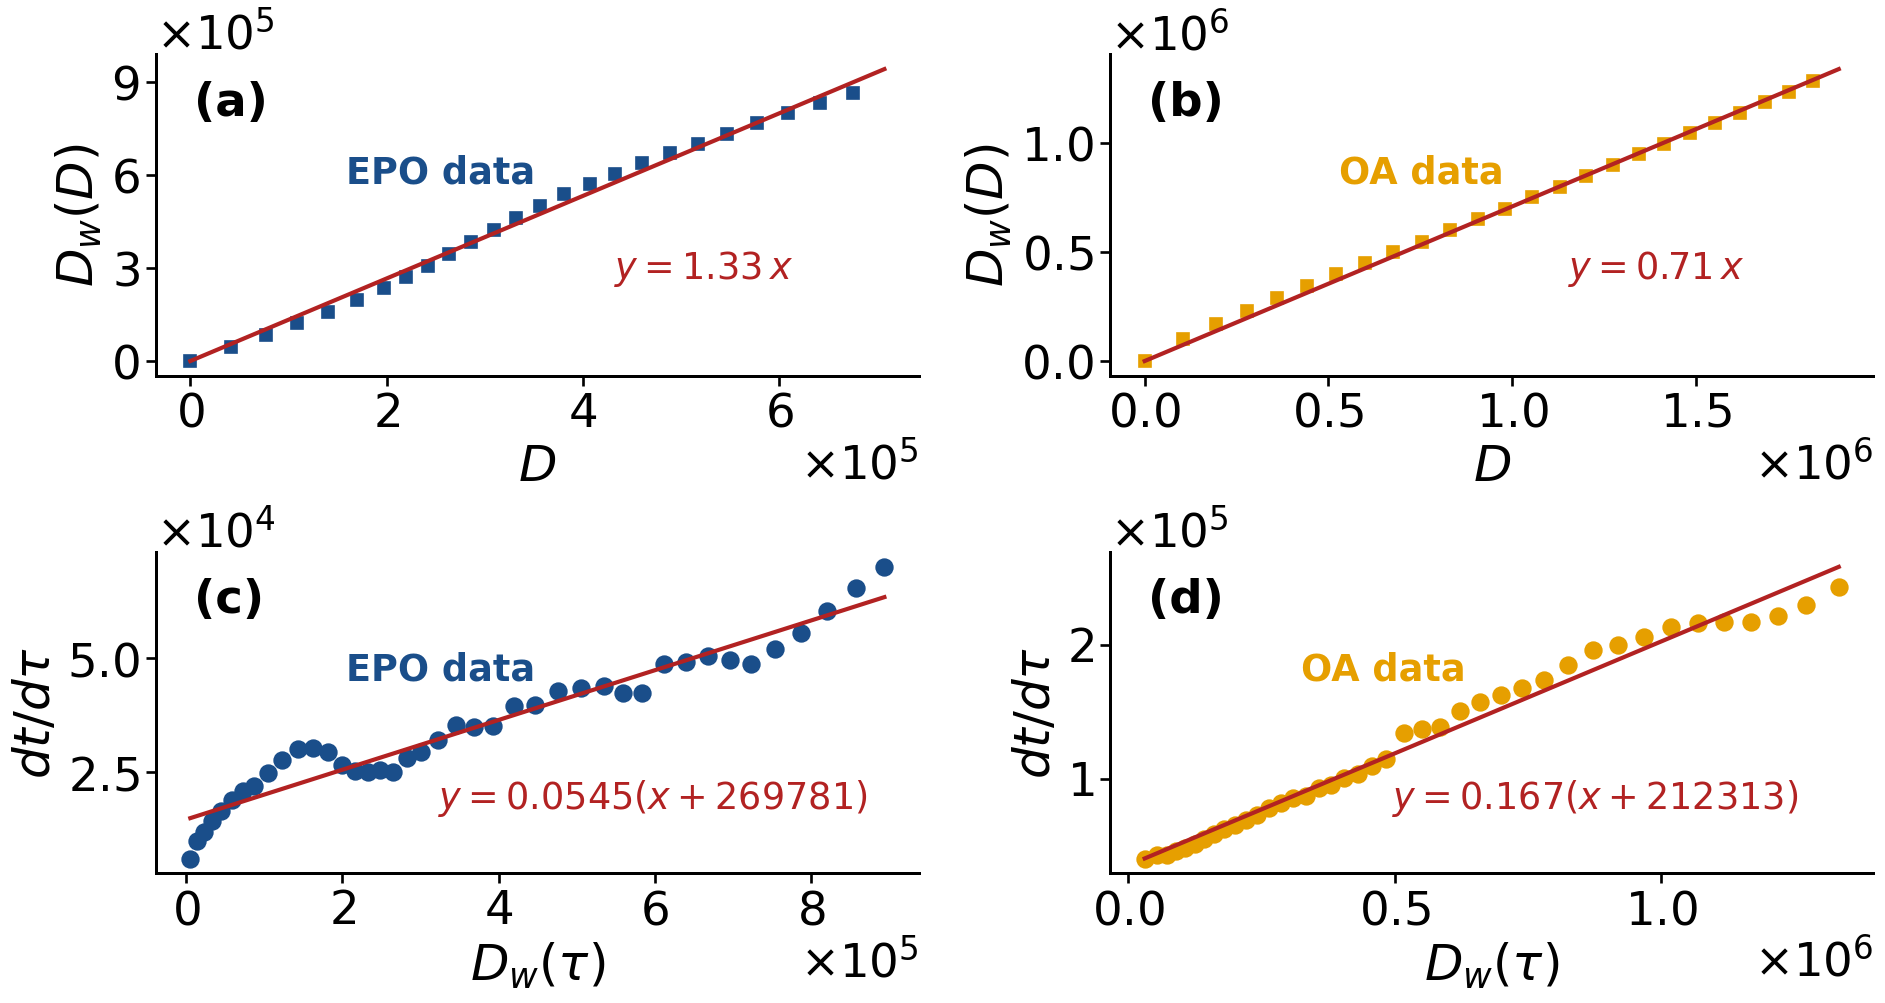

In [3]:
# Build the 2×2 figure with linear fits
fig, axs = plt.subplots(2, 2, figsize=(16, 9))
labels = ["(a)", "(b)", "(c)", "(d)"]

# --- (a) PATENTS: D_w(D) ---
X = np.array(all_ipc_lin_patents)
Y = np.array(all_first_authors_lin_patents)
a, _, _, _ = np.linalg.lstsq(X[:, np.newaxis], Y, rcond=None)
fit_line = a * X

ax = axs[0, 0]
ax.plot(X[::400], Y[::400], "s", markersize=7.5, color=colors[0])
ax.plot(X, fit_line, "-", lw=2.5, color=colors[1])
ax.set_xlabel(r"$D$")
ax.set_ylabel(r"$D_w(D)$")
ax.text(0.05, 0.81, labels[0], transform=ax.transAxes, fontsize=28, fontweight="bold")
ax.text(0.25, 0.60, "EPO data", transform=ax.transAxes, color=colors[0], fontsize=22, fontweight="bold")
ax.text(0.60, 0.30, fr"$y = {a[0]:.2f}\,x$", transform=ax.transAxes, color=colors[1], fontsize=22, fontweight="bold")
ax.set_yticks([0, 0.3 * 10**6, 0.6 * 10**6, 0.9 * 10**6])
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0), useMathText=True)

# --- (b) PAPERS: D_w(D) ---
X_papers = np.array(combos_lin_papers)
Y_papers = np.array(all_first_authors_lin_papers)
a_papers, _, _, _ = np.linalg.lstsq(X_papers[:, np.newaxis], Y_papers, rcond=None)
fit_line_papers = a_papers * X_papers

ax = axs[0, 1]
ax.plot(X_papers[::400], Y_papers[::400], "s", markersize=7.5, color=colors[2])
ax.plot(X_papers, fit_line_papers, "-", lw=2.5, color=colors[1])
ax.set_xlabel(r"$D$")
ax.set_ylabel(r"$D_w(D)$")
ax.text(0.05, 0.81, labels[1], transform=ax.transAxes, fontsize=28, fontweight="bold")
ax.text(0.30, 0.60, "OA data", transform=ax.transAxes, color=colors[2], fontsize=22, fontweight="bold")
ax.text(0.60, 0.30, fr"$y = {a_papers[0]:.2f}\,x$", transform=ax.transAxes, color=colors[1], fontsize=22, fontweight="bold")
ax.set_xticks([0, 0.5 * 10**6, 1 * 10**6, 1.5 * 10**6])
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0), useMathText=True)

# --- (c) PATENTS: dt/dτ vs w(τ) ---
m, q = np.polyfit(first_authors_patents, delta_rows_patents, 1)
fit_line = m * np.array(first_authors_patents) + q

ax = axs[1, 0]
ax.plot(first_authors_patents, delta_rows_patents, "o", color=colors[0])
ax.plot(first_authors_patents, fit_line, "-", lw=2.5, color=colors[1])
ax.set_xlabel(r"$D_w(\tau)$")
ax.set_ylabel(r"$dt/d\tau$")
ax.text(0.05, 0.81, labels[2], transform=ax.transAxes, fontsize=28, fontweight="bold")
ax.text(0.25, 0.60, "EPO data", transform=ax.transAxes, color=colors[0], fontsize=22, fontweight="bold")
ax.text(0.37, 0.20, fr"$y = {m:.4f}(x + {q / m:.0f})$", transform=ax.transAxes, color=colors[1], fontsize=22, fontweight="bold")
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0), useMathText=True)

# --- (d) PAPERS: dt/dτ vs w(τ) ---
m, q = np.polyfit(first_authors_papers, delta_rows_papers, 1)
fit_line = m * np.array(first_authors_papers) + q

ax = axs[1, 1]
ax.plot(first_authors_papers, delta_rows_papers, "o", color=colors[2])
ax.plot(first_authors_papers, fit_line, "-", lw=2.5, color=colors[1])
ax.set_xlabel(r"$D_w(\tau)$")
ax.set_ylabel(r"$dt/d\tau$")
ax.text(0.05, 0.81, labels[3], transform=ax.transAxes, fontsize=28, fontweight="bold")
ax.text(0.25, 0.60, "OA data", transform=ax.transAxes, color=colors[2], fontsize=22, fontweight="bold")
ax.text(0.37, 0.20, fr"$y = {m:.3f}(x + {q / m:.0f})$", transform=ax.transAxes, color=colors[1], fontsize=22, fontweight="bold")
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0), useMathText=True)

plt.tight_layout()
plt.subplots_adjust(hspace=0.55, wspace=0.25)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_DIR / "fig_6.pdf", bbox_inches="tight")
plt.show()


## Load author-date dictionaries and compute productivity rates

We load per-author event timelines for patents and papers, then compute yearly metrics: individual productivity `p(τ)`, total events `δt(τ)`, and active authors `w_active(τ)`.

In [4]:
# Helper to compute yearly productivity metrics from author-date dictionaries
def compute_yearly_metrics(author_dates):
    events_per_author_year = defaultdict(lambda: defaultdict(int))

    # Build per-year counts per author
    for author, events in author_dates.items():
        for ev in events:
            y = int(ev["year"])
            events_per_author_year[y][author] += 1

    years = sorted(events_per_author_year.keys())

    active_by_year = defaultdict(set)
    events_by_year = defaultdict(int)
    event_distributions = {}

    for y in years:
        dist = list(events_per_author_year[y].values())
        event_distributions[y] = np.array(dist)
        active_by_year[y] = set(events_per_author_year[y].keys())
        events_by_year[y] = np.sum(dist)

    # Cumulative total authors seen so far (not used in final plot, but available)
    authors_seen = set()
    W_total = {}
    for y in years:
        authors_seen |= active_by_year[y]
        W_total[y] = len(authors_seen)

    # Arrays for plotting
    A = np.array([len(active_by_year[y]) for y in years])
    E = np.array([events_by_year[y] for y in years])

    v = np.zeros(len(years))
    sigma_v = np.zeros(len(years))
    for i, y in enumerate(years):
        dist = event_distributions[y]
        v[i] = np.mean(dist)
        sigma_v[i] = np.std(dist)

    # Drop first year to align with original notebook convention
    return np.array(years[1:]), v[1:], sigma_v[1:], A[1:], E[1:]

# --- Patents author dates ---
with open(base_dir / "epo_author_dates_1980_2020.pkl", "rb") as f:
    author_dates_patent = pickle.load(f)

# --- Papers (OpenAlex) author dates ---
with open(base_dir / "openalex_author_dates_1980_2020.pkl", "rb") as f:
    author_dates_papers = pickle.load(f)

# Optional filter: remove authors with >100 events in any single year (as in original)
filtered = {}
for author, events in author_dates_papers.items():
    year_counts = Counter(int(ev["year"]) for ev in events)
    if any(count > 100 for count in year_counts.values()):
        continue
    filtered[author] = events

author_dates_papers = filtered

# Compute yearly metrics
years_pat, v_pat, sigma_v_pat, A_pat, E_pat = compute_yearly_metrics(author_dates_patent)
years_pap, v_pap, sigma_v_pap, A_pap, E_pap = compute_yearly_metrics(author_dates_papers)


## Plot rate figure (1×2) with twin y-axes

Left axis: individual productivity `p(τ)` with uncertainty band. Right axis (log): total events `δt(τ)` and active authors `w_active(τ)`.

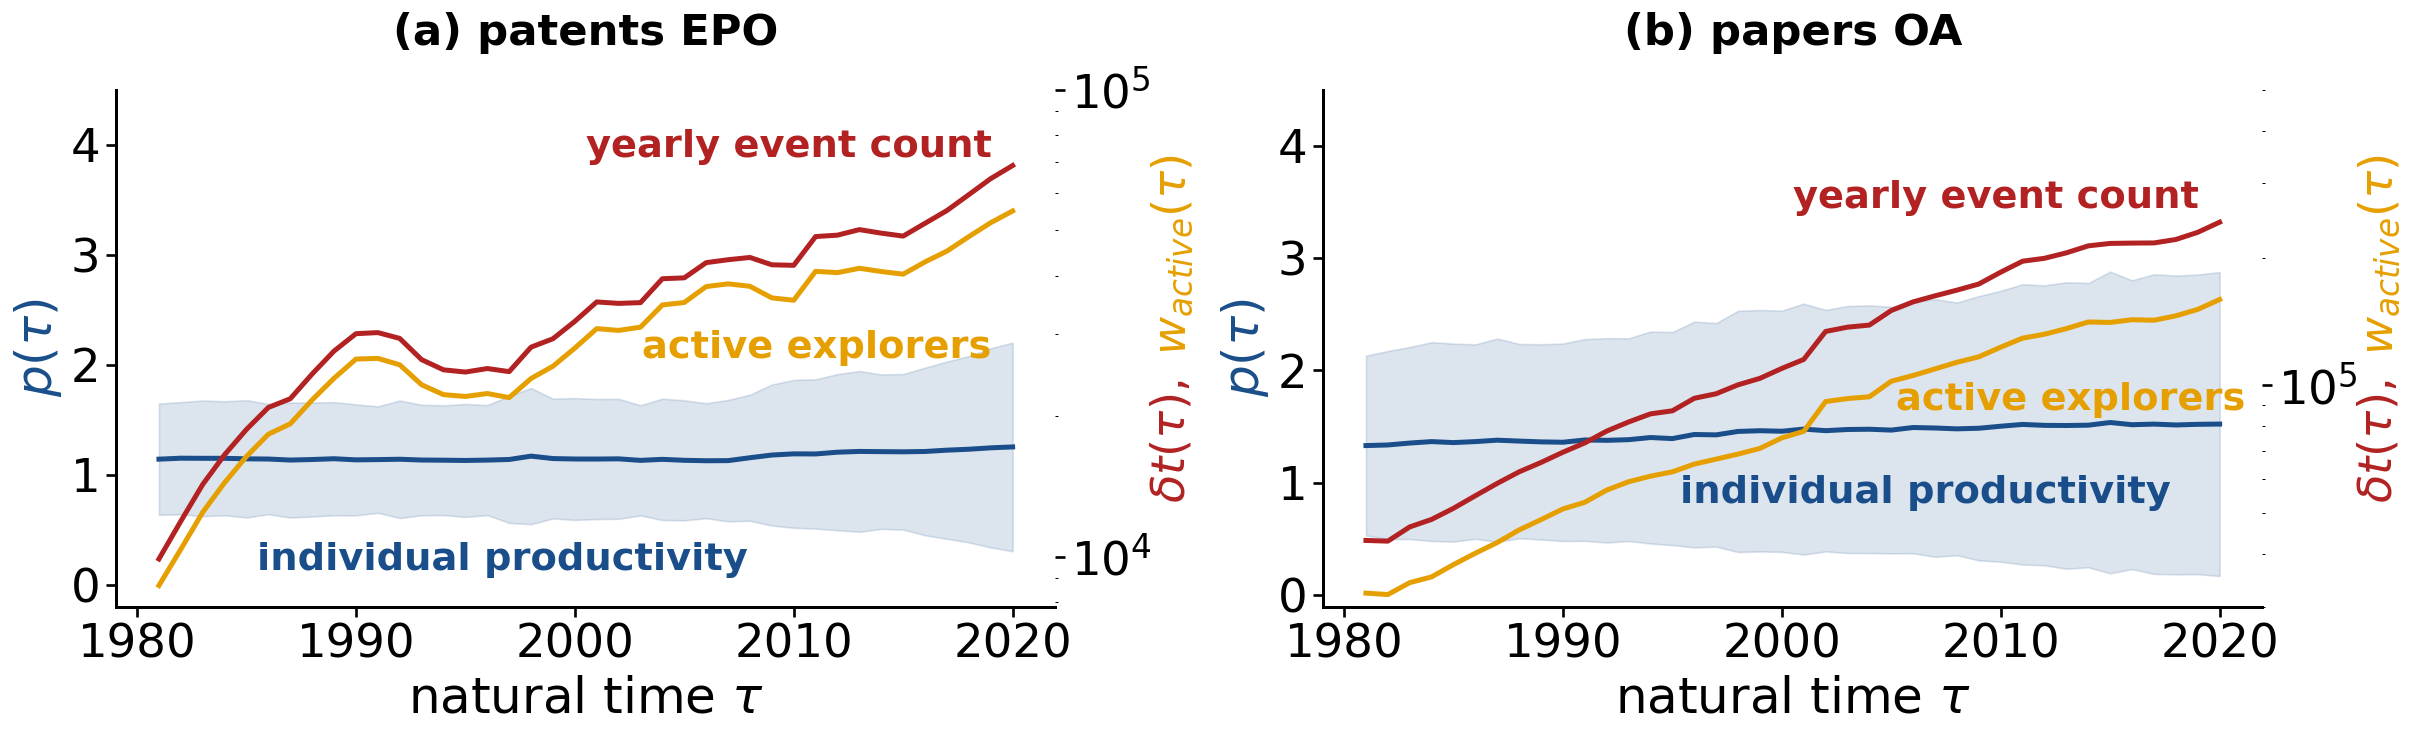

In [5]:
# Build the 1×2 rate figure with twin y-axes
fig, axes = plt.subplots(1, 2, figsize=(20, 6), constrained_layout=True)

color_p = colors[0]
color_dt = colors[1]
color_w = colors[2]

# --- (a) PATENTS EPO ---
ax1 = axes[0]
ax1.plot(years_pat, v_pat, color=color_p, lw=3)
ax1.fill_between(years_pat, v_pat - sigma_v_pat, v_pat + sigma_v_pat, color=color_p, alpha=0.15)
ax1.set_xlabel(r"natural time $\tau$")
ax1.set_ylabel(r"$p(\tau)$", color=color_p)
ax1.set_ylim(bottom=-0.2, top=4.5)

ax2 = ax1.twinx()
ax2.plot(years_pat, E_pat, color=color_dt, lw=3)
ax2.plot(years_pat, A_pat, color=color_w, lw=3)
ax2.set_yscale("log")
ax2.set_ylim(top=10**5)

ax2.text(1.1, 0.32, r"$\delta t(\tau)$,", transform=ax2.transAxes, rotation=90, va="center", ha="left", color=color_dt)
ax2.text(1.1, 0.68, r"$w_{active}(\tau)$", transform=ax2.transAxes, rotation=90, va="center", ha="left", color=color_w)

ax1.text(0.15, 0.07, r"individual productivity", transform=ax1.transAxes, color=color_p, fontsize=23, fontweight="bold")
ax2.text(0.50, 0.87, r"yearly event count", transform=ax2.transAxes, color=color_dt, fontsize=23, fontweight="bold")
ax2.text(0.56, 0.48, r"active explorers", transform=ax2.transAxes, color=color_w, fontsize=23, fontweight="bold")

ax1.text(0.5, 1.15, "(a) patents EPO", transform=ax1.transAxes, fontsize=26, fontweight="bold", va="top", ha="center")

# --- (b) PAPERS OPENALEX ---
ax1 = axes[1]
ax1.plot(years_pap, v_pap, color=color_p, lw=3)
ax1.fill_between(years_pap, v_pap - sigma_v_pap, v_pap + sigma_v_pap, color=color_p, alpha=0.15)
ax1.set_xlabel(r"natural time $\tau$")
ax1.set_ylabel(r"$p(\tau)$", color=color_p)
ax1.set_ylim(bottom=-0.1, top=4.5)

ax2 = ax1.twinx()
ax2.plot(years_pap, E_pap, color=color_dt, lw=3)
ax2.plot(years_pap, A_pap, color=color_w, lw=3)
ax2.set_yscale("log")
ax2.set_ylim(bottom=3 * 1e4, top=5 * 1e5)

ax2.text(1.10, 0.32, r"$\delta t(\tau)$,", transform=ax2.transAxes, rotation=90, va="center", ha="left", color=color_dt)
ax2.text(1.10, 0.68, r"$w_{active}(\tau)$", transform=ax2.transAxes, rotation=90, va="center", ha="left", color=color_w)

ax1.text(0.38, 0.20, r"individual productivity", transform=ax1.transAxes, color=color_p, fontsize=23, fontweight="bold")
ax2.text(0.50, 0.77, r"yearly event count", transform=ax2.transAxes, color=color_dt, fontsize=23, fontweight="bold")
ax2.text(0.61, 0.38, r"active explorers", transform=ax2.transAxes, color=color_w, fontsize=23, fontweight="bold")

ax1.text(0.5, 1.15, "(b) papers OA", transform=ax1.transAxes, fontsize=26, fontweight="bold", va="top", ha="center")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_DIR / "fig_1.pdf", bbox_inches="tight")
plt.show()


## Inter-event times for patents and papers

We use the precomputed inter-event time dictionaries (intertimes) for EPO patents and OpenAlex papers and print summary statistics for four cases: all events, global novelty only, any novelty (global + individual), and no novelty. All printed outputs are in English.


In [6]:
import pickle
import numpy as np
from pathlib import Path


def extract_years(interval_list):
    """Extract numeric interval lengths in years from a list of dicts."""
    if not interval_list:
        return np.array([])

    return np.array([x["interval_years"] for x in interval_list if "interval_years" in x])


def print_stats(dataset_label, interval_label, interval_list):
    print(f"=== {dataset_label} | {interval_label} ===")

    if not interval_list:
        print("No intervals available.")
        return

    arr = extract_years(interval_list)

    if arr.size == 0:
        print("No valid intervals after extraction.")
        return

    print(f"Total intervals: {len(arr):,}")
    print(f"Mean:   {np.mean(arr):.3f} years")
    print(f"Median: {np.median(arr):.3f} years")


def build_intervals_from_author_dates(author_dates):
    """Compute inter-event intervals from an author->events dictionary."""
    intervals = {
        "all_intervals": [],
        "global_only_intervals": [],
        "novelties_intervals": [],
        "no_novelty_intervals": [],
    }

    def to_day(d):
        try:
            return np.datetime64(d, "D")
        except Exception:
            return np.datetime64(str(d)[:10], "D")

    def add_intervals(date_list, out_list, author):
        if len(date_list) < 2:
            return
        for d1, d2 in zip(date_list[:-1], date_list[1:]):
            dt = (d2 - d1).astype("timedelta64[D]").astype(int) / 365.25
            if 0 < dt < 50:
                out_list.append({"interval_years": dt, "author": author})

    for author, events in author_dates.items():
        if not events or len(events) < 2:
            continue

        dates_all = [to_day(ev["date"]) for ev in events if "date" in ev]
        dates_all = sorted(dates_all)
        add_intervals(dates_all, intervals["all_intervals"], author)

        dates_global = [
            to_day(ev["date"]) for ev in events
            if ev.get("novelty_type") == "global_novelty" and "date" in ev
        ]
        dates_global = sorted(dates_global)
        add_intervals(dates_global, intervals["global_only_intervals"], author)

        dates_novel = [
            to_day(ev["date"]) for ev in events
            if ev.get("novelty_type") in ("global_novelty", "individual_novelty") and "date" in ev
        ]
        dates_novel = sorted(dates_novel)
        add_intervals(dates_novel, intervals["novelties_intervals"], author)

        dates_none = [
            to_day(ev["date"]) for ev in events
            if ev.get("novelty_type") == "no_novelty" and "date" in ev
        ]
        dates_none = sorted(dates_none)
        add_intervals(dates_none, intervals["no_novelty_intervals"], author)

    return intervals


def load_or_build(path, author_dates, label):
    if path.exists():
        with open(path, "rb") as f:
            return pickle.load(f)

    print(f"Note: {label} intervals file not found at {path}. Recomputing from author dates.")
    return build_intervals_from_author_dates(author_dates)


# Use the intertimes files in outputs (fallback to author_dates if missing)
pat_path = base_dir / "epo_intervals.pkl"
pap_path = base_dir / "openalex_intervals.pkl"

intervals_pat = load_or_build(pat_path, author_dates_patent, "Patents")
intervals_pap = load_or_build(pap_path, author_dates_papers, "Papers")


def print_all_stats(dataset_label, intervals):
    print_stats(dataset_label, "All events", intervals.get("all_intervals"))
    print_stats(dataset_label, "Global novelty only", intervals.get("global_only_intervals"))
    print_stats(dataset_label, "Any novelty (global + individual)", intervals.get("novelties_intervals"))
    print_stats(dataset_label, "No novelty", intervals.get("no_novelty_intervals"))


print_all_stats("Patents (EPO)", intervals_pat)
print_all_stats("Papers (OpenAlex)", intervals_pap)


=== Patents (EPO) | All events ===
Total intervals: 481,920
Mean:   2.342 years
Median: 0.977 years
=== Patents (EPO) | Global novelty only ===
Total intervals: 175,824
Mean:   2.800 years
Median: 1.246 years
=== Patents (EPO) | Any novelty (global + individual) ===


Total intervals: 426,320
Mean:   2.535 years
Median: 1.092 years
=== Patents (EPO) | No novelty ===
Total intervals: 23,000
Mean:   1.697 years
Median: 0.767 years
=== Papers (OpenAlex) | All events ===


Total intervals: 3,444,548
Mean:   1.664 years
Median: 0.753 years
=== Papers (OpenAlex) | Global novelty only ===
Total intervals: 45,934
Mean:   5.806 years
Median: 3.253 years
=== Papers (OpenAlex) | Any novelty (global + individual) ===


Total intervals: 2,448,589
Mean:   2.215 years
Median: 1.035 years
=== Papers (OpenAlex) | No novelty ===
Total intervals: 838,434
Mean:   1.579 years
Median: 0.745 years


## Career length and one-timers (patents vs papers)

We compute per-author career length as the time between the first and last event (in years).
We report mean ± standard deviation over authors with at least two events, and basic counts:
total authors, authors with ≥2 events, one-timers (exactly one event), and one-timer fraction.


In [7]:
import numpy as np

def career_lengths_fast(author_dates):
    lengths = []
    total_authors = len(author_dates)
    two_or_more = 0
    one_timers = 0

    for _, events in author_dates.items():
        n = len(events)
        if n == 0:
            continue
        if n == 1:
            one_timers += 1
            continue

        two_or_more += 1

        # ev["date"] is already datetime-like (Timestamp / np.datetime64).
        dmin = None
        dmax = None
        for ev in events:
            d = ev.get("date")
            if d is None:
                continue
            if dmin is None or d < dmin:
                dmin = d
            if dmax is None or d > dmax:
                dmax = d

        if dmin is None or dmax is None:
            continue

        dt_years = (dmax - dmin).total_seconds() / (365.25 * 24 * 3600)
        lengths.append(dt_years)

    lengths = np.asarray(lengths, dtype=float)
    one_timer_fraction = one_timers / total_authors if total_authors else np.nan
    return lengths, total_authors, two_or_more, one_timers, one_timer_fraction


def print_career_stats(label, author_dates):
    lengths, total_authors, two_or_more, one_timers, frac = career_lengths_fast(author_dates)
    print(f"=== {label} ===")
    print(f"Total authors: {total_authors:,}")
    print(f"Authors with ≥2 events: {two_or_more:,}")
    print(f"One-timers (1 event): {one_timers:,}")
    print(f"One-timer fraction: {frac:.4f}")

    if lengths.size == 0:
        print("No valid career lengths available.")
        return

    mean = np.mean(lengths)
    std = np.std(lengths)
    print(f"Career length (years): {mean:.3f} ± {std:.3f}")


print_career_stats("Patents (EPO)", author_dates_patent)
print_career_stats("Papers (OpenAlex)", author_dates_papers)


=== Patents (EPO) ===
Total authors: 887,421
Authors with ≥2 events: 220,200
One-timers (1 event): 667,221
One-timer fraction: 0.7519
Career length (years): 5.125 ± 6.226


=== Papers (OpenAlex) ===
Total authors: 1,332,990
Authors with ≥2 events: 619,550
One-timers (1 event): 713,440
One-timer fraction: 0.5352
Career length (years): 9.250 ± 9.509


## Author-year activity heatmaps (1980–2020)

We build a 1×2 panel (patents vs papers) using the already loaded `author_dates_patent` and `author_dates_papers` dictionaries. The x-axis is the calendar year (1980–2020, not rescaled) and the y-axis is the number of events per author-year. We plot a 2D histogram (log density) of author-year counts.


Patents points (author × year): 1,213,977
Papers points (author × year): 3,515,366


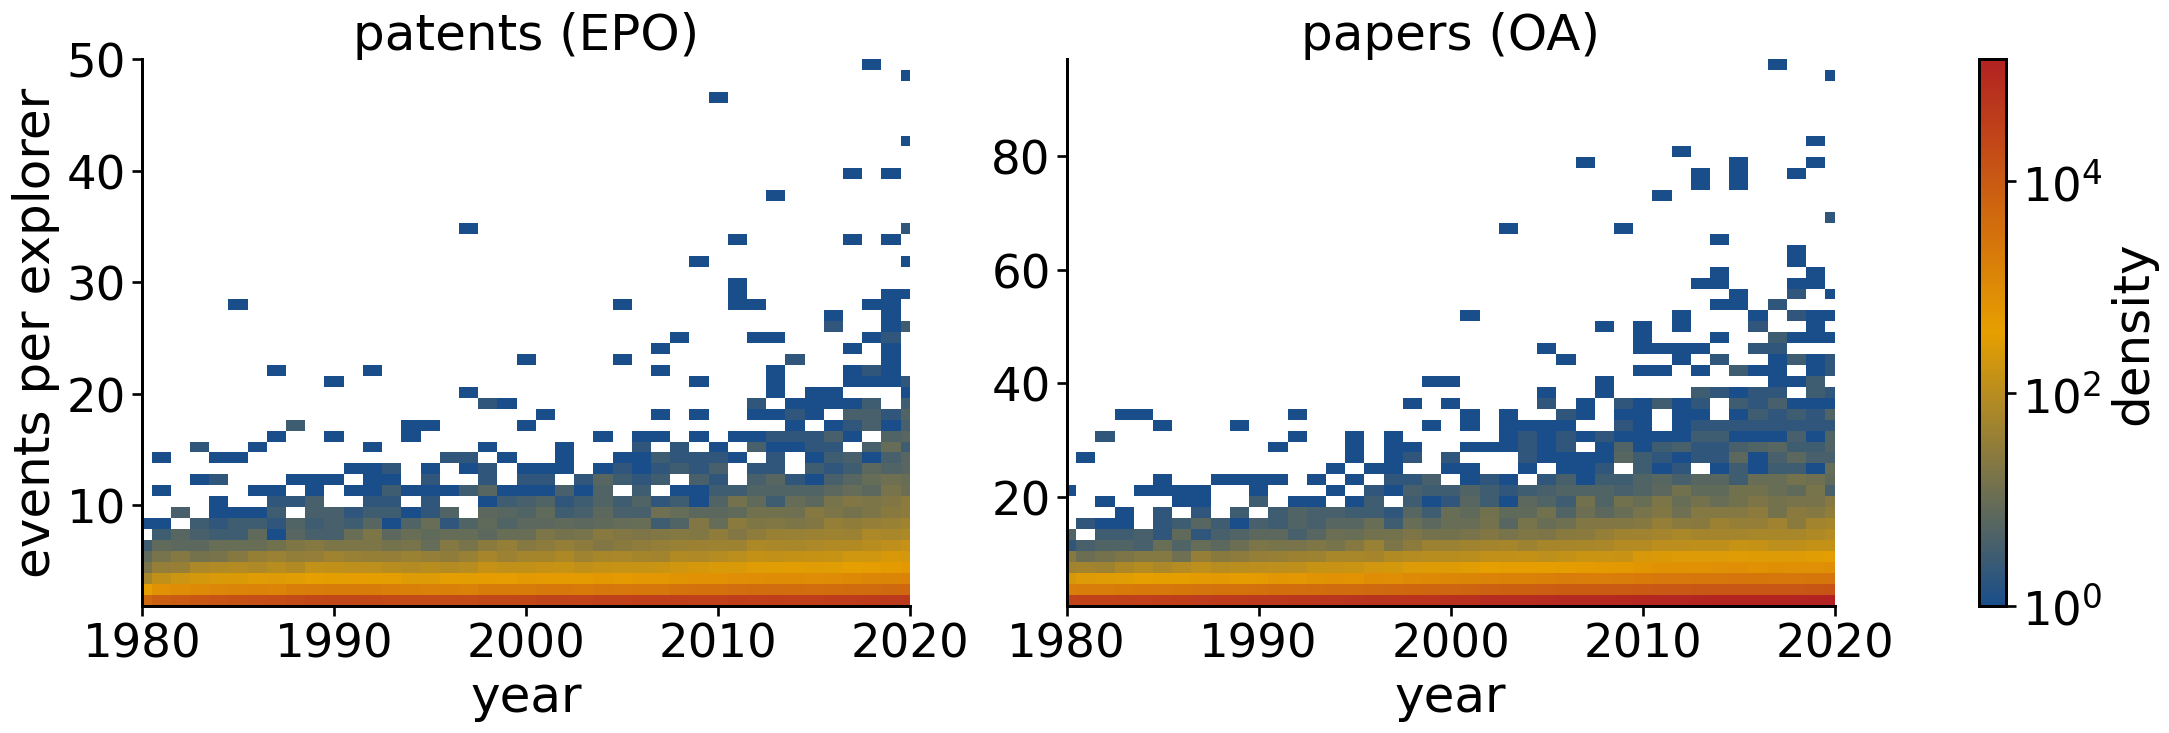

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm


def author_year_points(author_dates, year_min=1980, year_max=2020):
    """Build x=year and y=events-per-author-year arrays."""
    x_all = []
    y_all = []

    for author, events in author_dates.items():
        if not events:
            continue

        counts_per_year = {}
        for ev in events:
            yr = int(ev["year"])
            if yr < year_min or yr > year_max:
                continue
            counts_per_year[yr] = counts_per_year.get(yr, 0) + 1

        for yr, count in counts_per_year.items():
            x_all.append(yr)
            y_all.append(count)

    x = np.asarray(x_all)
    y = np.asarray(y_all)
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


x_pat, y_pat = author_year_points(author_dates_patent)
x_pap, y_pap = author_year_points(author_dates_papers)

print(f"Patents points (author × year): {len(x_pat):,}")
print(f"Papers points (author × year): {len(x_pap):,}")

# Bins and shared log-normalization
year_min, year_max = 1980, 2020
year_bins = np.arange(year_min - 0.5, year_max + 1.5, 1)

y_max = int(max(y_pat.max() if len(y_pat) else 0, y_pap.max() if len(y_pap) else 0))
if y_max <= 0:
    y_bins = np.arange(0.5, 1.5, 1)
elif y_max <= 60:
    y_bins = np.arange(0.5, y_max + 1.5, 1)
else:
    y_bins = 50

H_pat, _, _ = np.histogram2d(x_pat, y_pat, bins=[year_bins, y_bins])
H_pap, _, _ = np.histogram2d(x_pap, y_pap, bins=[year_bins, y_bins])
vmax = max(H_pat.max(), H_pap.max(), 1)

norm = LogNorm(vmin=1, vmax=vmax)

cmap_custom = LinearSegmentedColormap.from_list(
    "navy_gold_brick",
    ["#1A4E8A", "#E69F00", "#B22222"],
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

h1 = axes[0].hist2d(x_pat, y_pat, bins=[year_bins, y_bins], cmap=cmap_custom, norm=norm)
axes[0].set_title("patents (EPO)")
axes[0].set_xlabel("year")
axes[0].set_ylabel("events per explorer")
axes[0].set_xlim(year_min, year_max)

h2 = axes[1].hist2d(x_pap, y_pap, bins=[year_bins, y_bins], cmap=cmap_custom, norm=norm)
axes[1].set_title("papers (OA)")
axes[1].set_xlabel("year")
axes[1].set_xlim(year_min, year_max)

fig.colorbar(h2[3], ax=axes, label="density")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_DIR / "fig_SI1.pdf", bbox_inches="tight")
plt.show()
